## Emporium Sales 

In this project, I’m analyzing sales data for EmporiUm, a growing student bookstore chain that also sells tech gear, art supplies, and other products both in-store and online. The goal of this analysis is to compare sales performance across two territories and better understand what’s driving differences in sales.

------------------------------------------------
#### South Region Territories: Florida and Texas 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#### importing cvs files 

In [3]:
customers_df = pd.read_csv('EmporiUm_files/customer_list.csv', sep='|') # using '|' because this file doesn’t use commas to separate columns
customers_df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


In [4]:
products_df = pd.read_csv('EmporiUm_files/Products.csv')
products_df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


In [5]:
categories_df = pd.read_csv('EmporiUm_files/ProductCategories.csv')
categories_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


In [6]:
stores_df = pd.read_csv('EmporiUm_files/StoreDetail.csv')
stores_df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


In [7]:
sales_df = pd.read_csv('EmporiUm_files/StoreSales.csv')
sales_df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


## Core Marketing Analysis 

### 1. Who are the territory managers for the sales territories assigned? What are the store IDs and cities for the stores in each assigned sales territory?
Lana Ilana manages the Florida territory, while Jeff "Howdy" Richards manages the Texas territory. 
The table below displays the store IDs and locations for both territories.

In [8]:
# filters to include only Florida and Texas stores
south_stores = stores_df[
    (stores_df['State'] == 'Florida') | (stores_df['State'] == 'Texas')
]
# selects only the relevant columns needed 
territory_summary = south_stores[
    ['Territory Manager', 'Store ID', 'Store Location']
].drop_duplicates().sort_values(
    by=['Territory Manager', 'Store ID']
)
# displays territory manager, store ID, and store location summary
territory_summary.head()

,Territory Manager,Store ID,Store Location
100,"Jeff ""Howdy"" Richards",901,Arlington
101,"Jeff ""Howdy"" Richards",902,Austin
102,"Jeff ""Howdy"" Richards",903,Bacliff
103,"Jeff ""Howdy"" Richards",904,Baytown
104,"Jeff ""Howdy"" Richards",905,Beaumont


In [9]:
territory_summary.tail() # Displays territory manager, store ID, and store location summary. 

,Territory Manager,Store ID,Store Location
32,Lana Ilana,725,Naples
33,Lana Ilana,726,Orlando
34,Lana Ilana,727,Sebring
35,Lana Ilana,728,Tallahassee
36,Lana Ilana,729,Tampa


### 2. What is monthly total revenue for in-store sales in each of the two sales territories, over the full period covered by the data?
Based on the analysis, monthly in-store revenue for both Florida and Texas 
generally increased over time. Each territory experienced periods of strong 
sales growth, particularly in the later years of the dataset. Overall, both 
regions consistently generated high monthly revenue, indicating sustained 
customer demand and business performance.

In [10]:
# merging the sales data with store information using Store ID
# this allows me to connect each sale to a location and territory
south_sales = pd.merge(sales_df, stores_df, on='Store ID')


# filtering the merged dataset to include only the states assigned for analysis
# (Florida and Texas territories)
south_sales = south_sales[
    (south_sales['State'] == 'Florida') | (south_sales['State'] == 'Texas')]

In [11]:
# convert transaction date to datetime
south_sales['Transaction Date'] = pd.to_datetime(south_sales['Transaction Date'])

# create a new column for the month of each transaction
south_sales['Month'] = south_sales['Transaction Date'].dt.to_period('M')

# group monthly revenue totals for Florida and Texas
monthly_revenue = (
    south_sales.groupby(['Month', 'State'])['Sale Amount']
    .sum()
    .reset_index()
)

# display results
monthly_revenue.tail()

,Month,State,Sale Amount
91,2025-10,Texas,168955.72
92,2025-11,Florida,133022.84
93,2025-11,Texas,105400.74
94,2025-12,Florida,122408.27
95,2025-12,Texas,95570.59


### 3. How would you rank the sales performance of each store in each sales territory? Which are the top-performing stores?

Based on the analysis, Beaumont, Texas and Miami, Florida were the top performing stores, generating the highest total sales revenue among the stores analyzed. 

In [12]:
# merge sales data with store details using Store ID
# this allows me to connect each transaction to a specific store
# including its location and state (which I need for territory analysis)
territory_sales = pd.merge(sales_df, stores_df, on='Store ID')

# filter the merged data to include only Florida and Texas
territory_sales = territory_sales[
    (territory_sales['State'] == 'Florida') | (territory_sales['State'] == 'Texas')
]
# group by store and calculate total revenue 
store_performance = territory_sales.groupby(
    ['State', 'Store ID', 'Store Location']
)['Sale Amount'].sum().reset_index()

# sort stores from highest to lowest revenue
ranked_stores = store_performance.sort_values(
    by='Sale Amount',
    ascending=False
)
# reset index so ranking starts at 1 instead of 0
ranked_stores = ranked_stores.reset_index(drop=True)
ranked_stores.index += 1

# display top-performing stores
ranked_stores.head(10)

,State,Store ID,Store Location,Sale Amount
1,Texas,905,Beaumont,637818.90
2,Florida,724,Miami,618846.25
3,Florida,728,Tallahassee,541670.66
4,Texas,910,Fort Worth,351772.59
5,Florida,722,Key West,332620.43
6,Florida,719,Cape Canaveral,331956.13
7,Florida,721,Jacksonville,331667.08
8,Florida,727,Sebring,330848.14
9,Texas,909,Desoto,330720.12
10,Texas,906,Cedar Park,312628.27


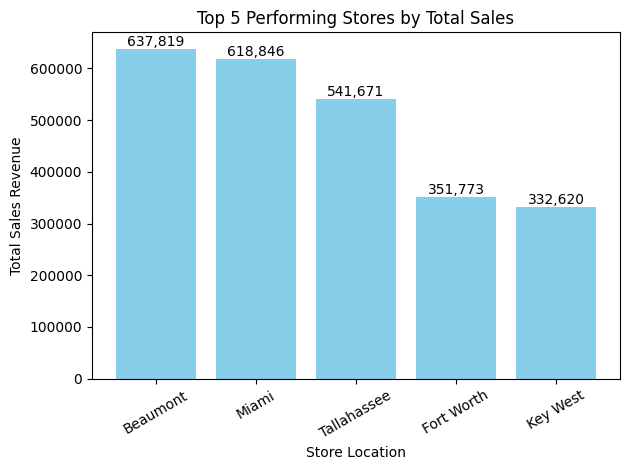

In [13]:
# create a bar chart to compare total sales across the top performing
# select top 5 stores
top_5_stores = ranked_stores.head(5)

# create bar chart
plt.bar(top_5_stores['Store Location'], top_5_stores['Sale Amount'], color='skyblue')

# title and labels
plt.title('Top 5 Performing Stores by Total Sales')
plt.xlabel('Store Location')
plt.ylabel('Total Sales Revenue')

# rotate labels
plt.xticks(rotation=30)

# add values on top of bars
for i, value in enumerate(top_5_stores['Sale Amount']):
    plt.text(i, value, f'{value:,.0f}', ha='center', va='bottom')

# adjust layout
plt.tight_layout()

plt.show()

### 4. Comparing the customer ID from the customer list data with the rewards ID from the sales data,who were the top customers in each sales territory?
The analysis identifies the top customers in both Florida and Texas based on total spending. 
These customers have the highest purchase amounts within their respective territories, 
making them key contributors to overall revenue.

In [23]:
# merge sales data with store details so we know the territory for each sale
territory_sales = pd.merge(sales_df, stores_df, on='Store ID')

# filter to only Florida and Texas
territory_sales = territory_sales[
    (territory_sales['State'] == 'Florida') | (territory_sales['State'] == 'Texas')
]
# merge with customer data to match each sale with a customer name
customer_sales = pd.merge(
    territory_sales,
    customers_df,
    left_on='RewardsID',
    right_on='cust_id'
)

In [24]:
# group customers by state and name to calculate total spending
top_customers = customer_sales.groupby(
    ['State', 'name']
)['Sale Amount'].sum().reset_index()

# sort customers from highest to lowest spending to identify top customers
top_customers = top_customers.sort_values(
    by='Sale Amount',
    ascending=False
)

# reset index for clean ranking
top_customers = top_customers.reset_index(drop=True)
top_customers.index += 1

# display the top 10 customers
top_customers.head(10)

,State,name,Sale Amount
1,Texas,Nate Jacobs,5240.86
2,Florida,Stanley H.,4954.99
3,Florida,Todd Chavez,4549.16
4,Florida,Huck,4415.78
5,Florida,John Locke,3631.94
6,Florida,Dr. Ray Flemming,3535.88
7,Texas,Christopher Moltisanti,3479.46
8,Texas,Jodie L.,3464.91
9,Texas,Darius,3400.35
10,Florida,Ernie,3387.58


### 5. What is the number of transactions per month by product category in each assigned territory? What is total sales revenue per month by category? What might this tell you about the most popular products, and where could there be opportunity for growth?

The results show that categories like Technology & Accessories and Stationery and 
Supplies are the most popular since they have both high transaction counts and high 
revenue in Florida and Texas. This means customers are buying these products more 
often and spending more on them.

On the other hand, categories with fewer transactions and lower revenue, like Books 
or Art Supplies, may be areas where the company could grow. These categories might 
benefit from more promotion or better product options to increase sales.

Overall, the data shows which products customers prefer and highlights areas where 
sales could be improved.

In [25]:
# combining sales, product, category, and store data
# merge sales with product data so I can connect each sale to a specific product
# this gives me product details like category and subcategory IDs needed for analysis
sales_data = pd.merge(sales_df, products_df, on='Prod Num')


# merge with category data so I can get actual category names instead of just IDs
# this is important because the question asks about product categories, not ID numbers
sales_data = pd.merge(
    sales_data,
    categories_df,
    on=['CategoryID', 'SubcategoryID']
)
# merge with store details so I can see where each sale happened
# this adds state and territory information needed to compare Florida and Texas
sales_data = pd.merge(sales_data, stores_df, on='Store ID')

#### 5a. Number of Transactions per Month by Category to understand how often products are purchased, I calculated the number of transactions per month by product category for Florida and Texas.

In [26]:
# filter for Florida and Texas
south_sales = sales_data[
    (sales_data['State'] == 'Florida') |
    (sales_data['State'] == 'Texas')
]
# convert transaction date
south_sales['Transaction Date'] = pd.to_datetime(south_sales['Transaction Date'])

# create month column
south_sales['Month'] = south_sales['Transaction Date'].dt.to_period('M')

# group and count transactions
transactions_per_month = south_sales.groupby(
    ['Month', 'State', 'Category']
)['Sale Amount'].count().reset_index()

# rename column
transactions_per_month = transactions_per_month.rename(
    columns={'Sale Amount': 'Transaction Count'}
)
# sort and display
transactions_per_month.sort_values(
    by='Transaction Count',
    ascending=False
).head(10)

,Month,State,Category,Transaction Count
483,2025-05,Florida,Stationery and Supplies,315
544,2025-10,Florida,Technology & Accessories,312
495,2025-06,Florida,Stationery and Supplies,282
469,2025-04,Florida,Art Supplies,273
550,2025-10,Texas,Technology & Accessories,271
471,2025-04,Florida,Stationery and Supplies,270
489,2025-05,Texas,Stationery and Supplies,267
501,2025-06,Texas,Stationery and Supplies,256
480,2025-05,Florida,Apparel and Merchandise,256
481,2025-05,Florida,Art Supplies,255


#### 5b. Total sales revenue per Month by Category, I calculated the total monthly revenue by product category for both territories.

In [27]:
# merge sales with product data so each sale is linked to a product
sales_data = pd.merge(sales_df, products_df, on='Prod Num')

# merge with category data to include product category names
sales_data = pd.merge(
    sales_data,
    categories_df,
    on=['CategoryID', 'SubcategoryID']
)
# merge with store data to include state and location information
sales_data = pd.merge(sales_data, stores_df, on='Store ID')

# filter the dataset to only include Florida and Texas
sales_data = sales_data[
    (sales_data['State'] == 'Florida') | (sales_data['State'] == 'Texas')
]
# convert transaction date to datetime so it can be grouped by time
sales_data['Transaction Date'] = pd.to_datetime(sales_data['Transaction Date'])

# create a month column for analysis
sales_data['Month'] = sales_data['Transaction Date'].dt.to_period('M')

In [28]:
# calculate total revenue per month by category and state
revenue_per_month = sales_data.groupby(
    ['Month', 'State', 'Category']
)['Sale Amount'].sum().reset_index()

# display results
revenue_per_month.tail(10)

,Month,State,Category,Sale Amount
566,2025-12,Florida,Books (General),2275.34
567,2025-12,Florida,Stationery and Supplies,1807.28
568,2025-12,Florida,Technology & Accessories,93257.11
569,2025-12,Florida,Textbooks,15160.56
570,2025-12,Texas,Apparel and Merchandise,5471.92
571,2025-12,Texas,Art Supplies,4027.32
572,2025-12,Texas,Books (General),2124.53
573,2025-12,Texas,Stationery and Supplies,1707.14
574,2025-12,Texas,Technology & Accessories,70285.94
575,2025-12,Texas,Textbooks,12395.43


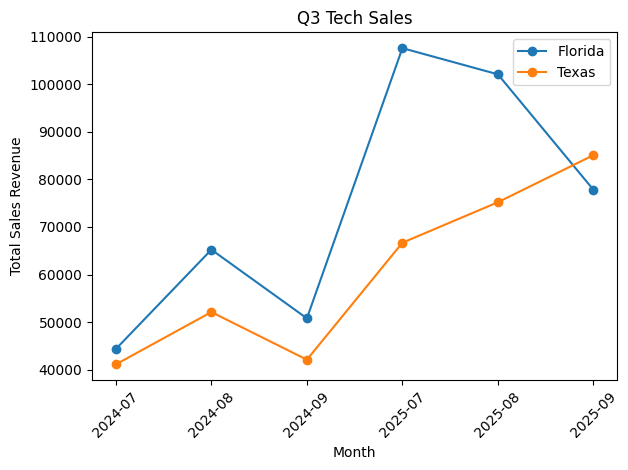

In [30]:
# sort the data by month 
revenue_per_month = revenue_per_month.sort_values(by='Month')


# filter to only include the most recent 2 years since this is more relevant
# for predicting what might happen next quarter
recent_data = revenue_per_month[
    revenue_per_month['Month'].astype(str).str.startswith('2024') |
    revenue_per_month['Month'].astype(str).str.startswith('2025')
]
# narrow the data down to Q3 months (July, August, September)
# because I want to focus on the time period leading into the next quarter
q3_data = recent_data[
    recent_data['Month'].astype(str).str.contains('-07|-08|-09')
]

# focus on Technology & Accessories since this is the top-performing category
# and the one I recommended for marketing focus
q3_data = q3_data[q3_data['Category'] == 'Technology & Accessories']


# separate Florida and Texas so I can compare their trends
fl_data = q3_data[q3_data['State'] == 'Florida']
tx_data = q3_data[q3_data['State'] == 'Texas']


# plot both states on the same chart to compare how revenue behaves across Q3
# using only two lines keeps the chart simple and easy to read
plt.plot(fl_data['Month'].astype(str), fl_data['Sale Amount'], marker='o', label='Florida')
plt.plot(tx_data['Month'].astype(str), tx_data['Sale Amount'], marker='o', label='Texas')


# add title and labels so it's clear what the chart is showing
plt.title('Q3 Tech Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales Revenue')


# rotate labels so they don't overlap and are easier to read
plt.xticks(rotation=45)


# show which line represents each state
plt.legend()


# adjust spacing so everything fits nicely on the chart
plt.tight_layout()


# display the final chart
plt.show()

### 6. What is your recommendation for where to focus marketing attention in the next quarter? 

Based on the Q3 analysis from the last two years, I recommend focusing 
marketing efforts on Technology & Accessories. This category consistently 
performs strongly during July through September in both Florida and Texas, 
which suggests stable and repeatable demand during this period.

Because this pattern is consistent across both territories, a similar 
marketing strategy could be applied in each. Focusing on this category 
heading into the next quarter would likely help maximize revenue.